# Unified Photometry

In [1]:
import warnings
warnings.filterwarnings("ignore")
from astropy.table import Table, Column, vstack
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u
import numpy as np
import pandas as pd
from utils import *
from catalog import *
from photometry import *

In [3]:
ra, dec = 175.2, 41.415
cli = PS()
cli.get_catalog(ra, dec, save_path='/home/liangrd/Follow_up/optical_data/EP260224a')

Saved PS catalog to /home/liangrd/Follow_up/optical_data/EP260224a/ps.csv


,objName,objAltName1,objAltName2,objAltName3,objID,uniquePspsOBid,ippObjID,surveyID,htmID,zoneID,...,yMeanKronMag,yMeanKronMagErr,yMeanKronMagStd,yMeanKronMagNpt,yMeanApMag,yMeanApMagErr,yMeanApMagStd,yMeanApMagNpt,yFlags,distance
0,PSO J175.1489+41.3351,NaN,NaN,NaN,157601751489822754,3605916000027271,249730873453193,0,15463790978318,15760,...,NaN,NaN,NaN,0,23.675301,0.275057,NaN,1,20536,0.088654
1,PSO J175.1301+41.3390,NaN,NaN,NaN,157601751301817466,3605916000023962,249730873449884,0,15463794378601,15760,...,19.055300,0.123305,0.599903,8,19.128401,0.060368,0.281182,9,115000,0.092336
2,PSO J175.1201+41.3406,NaN,NaN,NaN,157601751201669337,3605916000022182,249730873448104,0,15463794572779,15760,...,19.929501,0.165428,NaN,1,19.898500,0.125982,NaN,1,16892216,0.095572
3,PSO J175.1165+41.3381,NaN,NaN,NaN,157601751165556290,3605916000021553,249730873447475,0,15463794566616,15760,...,NaN,NaN,NaN,0,NaN,NaN,NaN,0,114720,0.099210
4,PSO J175.2254+41.3193,NaN,NaN,NaN,157581752254713813,3605916000041026,249730873466948,0,15463789017908,15758,...,21.098499,0.310593,NaN,1,20.907301,0.181151,NaN,1,115000,0.097529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,PSO J175.3161+41.4588,NaN,NaN,NaN,157751753160531136,3605916000057967,249730873483889,0,15463668381126,15775,...,NaN,NaN,NaN,0,NaN,NaN,NaN,0,16416,0.097388
458,PSO J175.1559+41.4787,NaN,NaN,NaN,157771751559705174,3605916000028655,249730873454577,0,15463675523214,15777,...,20.662600,0.301956,NaN,1,20.529301,0.161107,NaN,1,115000,0.071801
459,PSO J175.1603+41.4781,NaN,NaN,NaN,157771751603284060,3605916000029423,249730873455345,0,15463675525188,15777,...,NaN,NaN,NaN,0,NaN,NaN,NaN,0,16416,0.069738
460,PSO J175.1725+41.4767,NaN,NaN,NaN,157771751725222513,3605916000031665,249730873457587,0,15463675542137,15777,...,NaN,NaN,NaN,0,NaN,NaN,NaN,0,16416,0.064978


In [2]:
fits_dir = '/Volumes/T7/Shared_Files/EP/Results/Follow_up/optical_data/WXT J030902+581637/stack_WXT_J030902+581637_rp_wcs.fits'
fpath = '/Volumes/T7/Shared_Files/EP/Results/Follow_up/optical_data/WXT J030902+581637/'
ps_dir = '/Volumes/T7/Shared_Files/EP/Results/Follow_up/optical_data/WXT J030902+581637/ps.csv'

In [3]:
phot = Photometry()
phot.read_image(fits_dir)

Image and WCS loaded successfully.


In [4]:
zp_res = phot.compute_zeropoint(ps_dir=ps_dir,path=fpath,mag_col='r',mag_cut=15.)

Estimated FWHM: 1.9+/-0.1 pixels
Zeropoint: 27.583 ± 0.103 mag (N=234)


Text(0, 0.5, 'ZP')

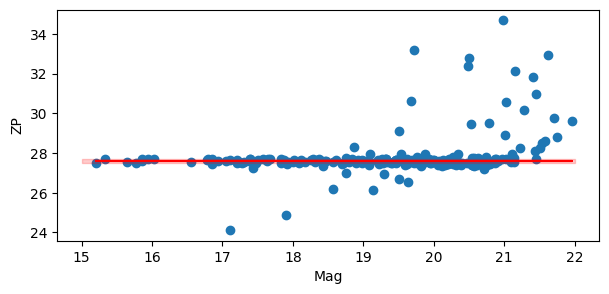

In [5]:
'Check ZP Fitting and you can apply magnitude cut (mag_cut) to exclude bright srats'
import matplotlib.pyplot as plt
zp_values = zp_res['zp_values']
pesu_x = zp_res['mag']

fig, ax = plt.subplots(figsize=(7,3),dpi=100)
ax.scatter(pesu_x, zp_values, label='ZP values')
ax.plot(pesu_x, np.full_like(pesu_x, zp_res['zeropoint']), color='red', label='ZP fit')
ax.fill_between(np.linspace(15,22),zp_res['zeropoint'] - zp_res['zp_std'], zp_res['zeropoint'] + zp_res['zp_std'], color='red', alpha=0.2)
ax.set_xlabel('Mag')
ax.set_ylabel('ZP')

Assign FWHM: 1.9455215236290413 pixels


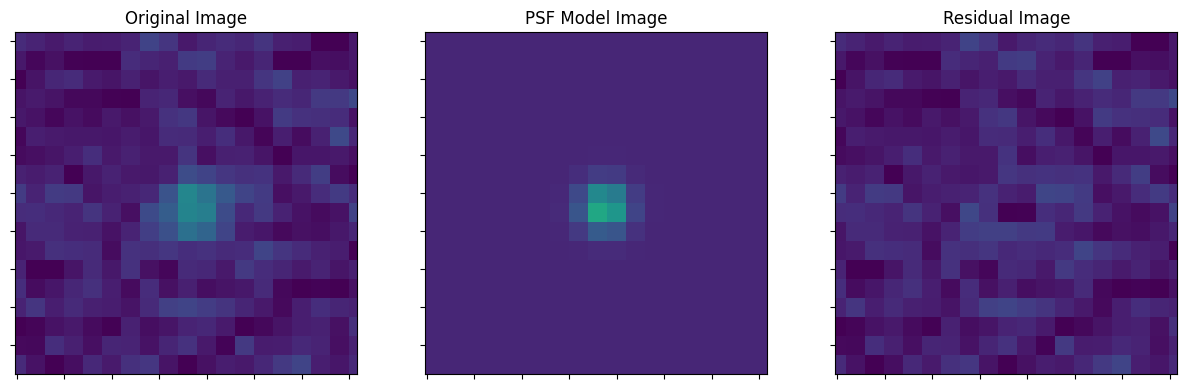

In [6]:
'PSF Photometry after ZP calibration'
#EP251229a
ra, dec = 62.5025, -1.4792
res = phot.psf_photometry(ra=ra,dec=dec)

x,y,flux,flux_err,mag,mag_err
float64,float64,float64,float64,float64,float64
927.8644680244108,539.9840696010094,151406.5633272403,139.500453453213,14.633000156219403,0.10257840522393091


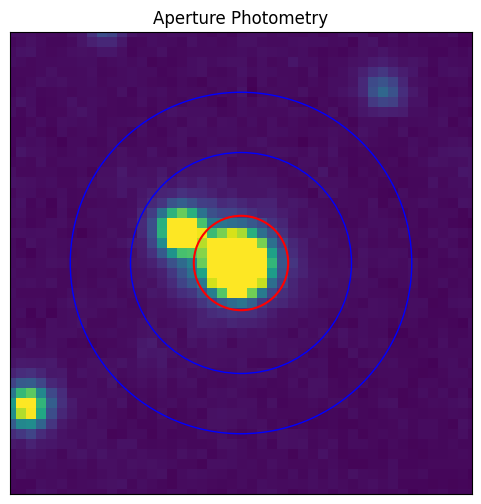

In [27]:
ra, dec = 47.2515, 58.26156
phot.aperture_photometry(ra=ra,dec=dec,aperture_radius=4.7,annulus_radii=(11,17))

In [28]:
phot.phot

x,y,flux,flux_err,mag,mag_err
float64,float64,float64,float64,float64,float64
927.8644680244108,539.9840696010094,151406.5633272403,139.500453453213,14.633000156219403,0.10257840522393091
